<a href="https://www.kaggle.com/code/gpreda/jigsaw-data-analysis?scriptVersionId=266518836" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br><br><br>
<center><img src="https://images.unsplash.com/photo-1494059980473-813e73ee784b" width=600></img></center>
<br><br><br>

# Introduction

In the past, I used to perform data analysis on some of the Jigsaw competition datasets. Here is one example: [Jigsaw EDA](https://www.kaggle.com/code/gpreda/jigsaw-eda).

With this Notebook, I will try an analysis on the current competition data.




<img src="https://images.unsplash.com/photo-1591040092219-081fb773589c" width=300></img>

# Analysis preparation


## Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import math
import json
import string
import warnings
from typing import Dict, Any, List, Tuple, Optional

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Load data

In [2]:
train_df = pd.read_csv("/kaggle/input/jigsaw-agile-community-rules/train.csv")

In [3]:
test_df = pd.read_csv("/kaggle/input/jigsaw-agile-community-rules/test.csv")

## Glimpse the data

In [4]:
train_df.shape, test_df.shape

((2029, 9), (10, 8))

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              2029 non-null   int64 
 1   body                2029 non-null   object
 2   rule                2029 non-null   object
 3   subreddit           2029 non-null   object
 4   positive_example_1  2029 non-null   object
 5   positive_example_2  2029 non-null   object
 6   negative_example_1  2029 non-null   object
 7   negative_example_2  2029 non-null   object
 8   rule_violation      2029 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 142.8+ KB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   row_id              10 non-null     int64 
 1   body                10 non-null     object
 2   rule                10 non-null     object
 3   subreddit           10 non-null     object
 4   positive_example_1  10 non-null     object
 5   positive_example_2  10 non-null     object
 6   negative_example_1  10 non-null     object
 7   negative_example_2  10 non-null     object
dtypes: int64(1), object(7)
memory usage: 772.0+ bytes


In [7]:
train_df.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1


In [8]:
test_df.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2
0,2029,NEW RAP GROUP 17. CHECK US OUT https://soundcl...,"No Advertising: Spam, referral links, unsolici...",hiphopheads,"Hey, guys, just wanted to drop in and invite y...",Cum Swallowing Hottie Katrina Kaif Cartoon Xvi...,SD Stream Eng - [Chelsea TV USA](http://soccer...,HD Streams: |[ENG HD Stoke vs Manchester Unite...
1,2030,Make your life comfortable. Get up to 15% Disc...,No legal advice: Do not offer or request legal...,AskReddit,Get a lawyer and get the security camera foota...,That isn't drastic. You tried reaching out to ...,So what are you going to do with the insurance...,It's just for Austria & Germany. If you still ...
2,2031,Kickin' ass and selling underwear!\nJust made ...,"No Advertising: Spam, referral links, unsolici...",gonewild,Good story my friend. Check out my blog at ht...,If you know what exactly you need then you don...,CENTIPEDES\n\nSOME BASED PATRIOTS HAVE CREATED...,[So great! Thanks for sharing.](http://www.che...
3,2032,watch hooters best therein http://clickan...,"No Advertising: Spam, referral links, unsolici...",personalfinance,"Earn 50,000 bonus points with Chase Sapphire P...","Cool, front page! I made this print along with...",[Full HD Movie Online Free](http://www.flickma...,* Karambit Black Pearl\n* 0.02137822 Float (un...
4,2033,bitches for free at this point show all h...,"No Advertising: Spam, referral links, unsolici...",Showerthoughts,code free tyrande --->>> [Imgur](http://i.imgu...,My trade link\nhttps://steamcommunity.com/trad...,**HD** [ mio Stadium 102 HD](http://www.genti....,Infographics is an incredible method for showi...


<img src="https://images.unsplash.com/photo-1591040092219-081fb773589c" width=300></img>

# Data analysis



/tmp/ipykernel_13/3307112347.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


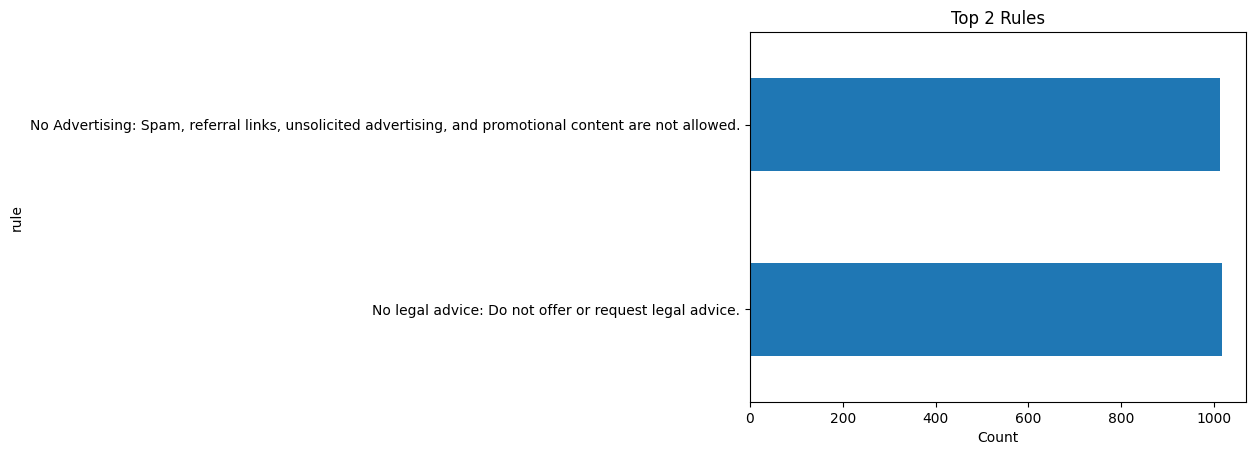

In [9]:
top_n = 2
counts = train_df["rule"].value_counts()
plt.figure()
counts.plot(kind="barh")
plt.title(f"Top {top_n} Rules")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

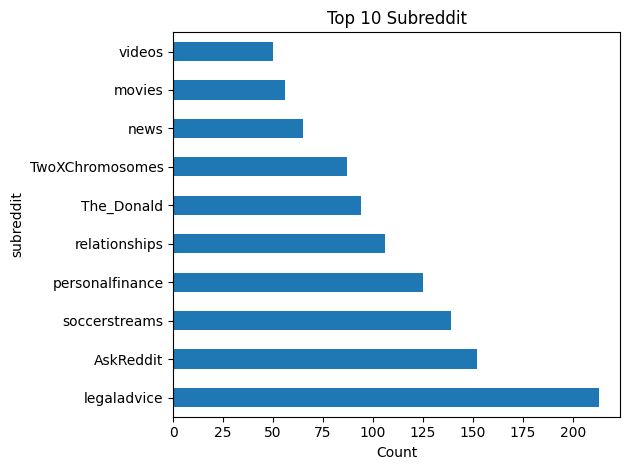

In [10]:
top_n = 10
counts = train_df["subreddit"].value_counts().head(top_n)
plt.figure()
counts.plot(kind="barh")
plt.title(f"Top {top_n} Subreddit")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

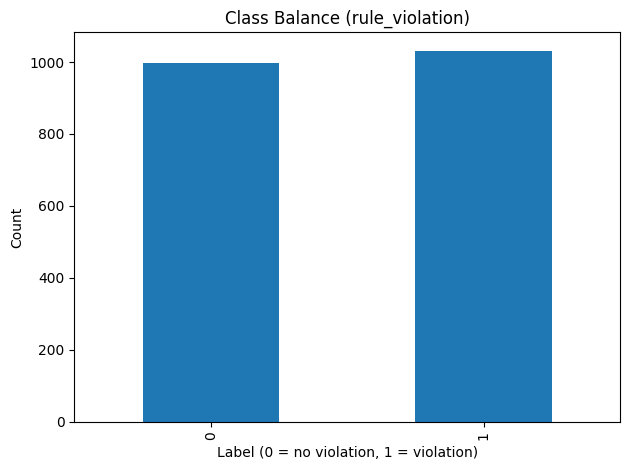

In [11]:
counts = train_df["rule_violation"].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("Class Balance (rule_violation)")
plt.xlabel("Label (0 = no violation, 1 = violation)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [12]:
def add_length_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add length features for EDA: char_len, word_len, avg_word_len."""
    def _tokenize(s: str) -> List[str]:
        return [w for w in re.findall(r"[A-Za-z0-9']+", s.lower())]

    char_len = df["body"].astype(str).str.len()
    word_len = df["body"].astype(str).apply(lambda s: len(_tokenize(s)))
    avg_word_len = []
    for s in df["body"].astype(str):
        toks = re.findall(r"[A-Za-z0-9']+", s.lower())
        avg_word_len.append(np.mean([len(t) for t in toks]) if toks else 0.0)

    df = df.copy()
    df["char_len"] = char_len
    df["word_len"] = word_len
    df["avg_word_len"] = avg_word_len
    return df


In [13]:
train_df = add_length_features(train_df)

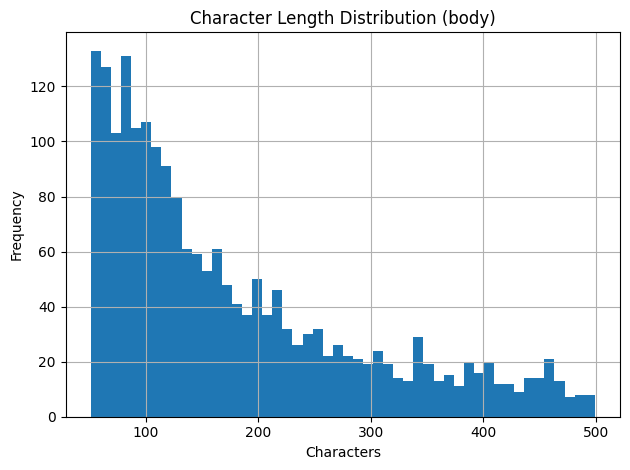

In [14]:
plt.figure()
train_df["char_len"].hist(bins=50)
plt.title("Character Length Distribution (body)")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

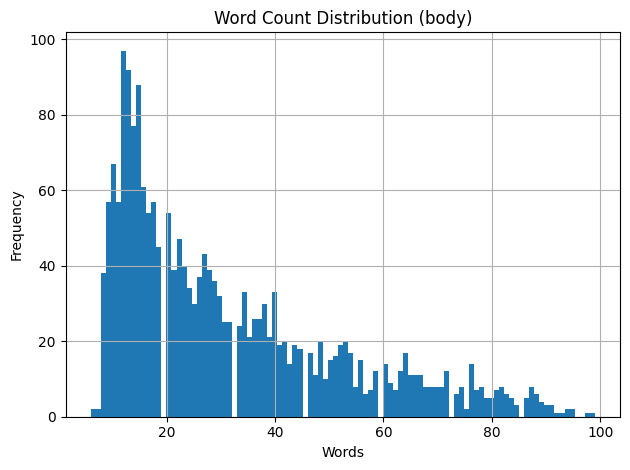

In [15]:
plt.figure()
train_df["word_len"].hist(bins=100)
plt.title("Word Count Distribution (body)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

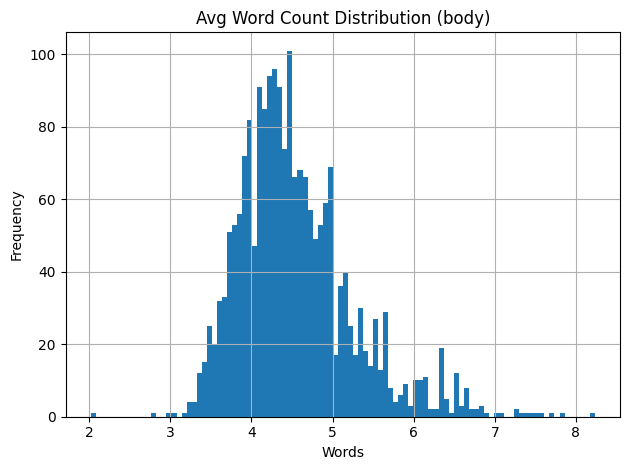

In [16]:
plt.figure()
train_df["avg_word_len"].hist(bins=100)
plt.title("Avg Word Count Distribution (body)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

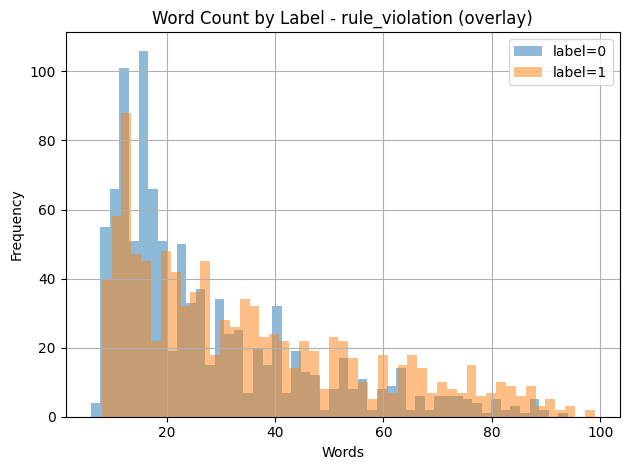

In [17]:
plt.figure()
train_df[train_df["rule_violation"] == 0]["word_len"].hist(bins=50, alpha=0.5, label="label=0")
train_df[train_df["rule_violation"] == 1]["word_len"].hist(bins=50, alpha=0.5, label="label=1")
plt.legend()
plt.title("Word Count by Label - rule_violation (overlay)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
rule_ct = (
    train_df.groupby(["rule", "rule_violation"])["row_id"]
    .count()
    .unstack(fill_value=0)
    .sort_values(by=1, ascending=False)
    .head(15)
)

print("Rules by # of violations:\n")
rule_ct = rule_ct.reset_index()
rule_ct

Rules by # of violations:



rule_violation,rule,0,1
0,No legal advice: Do not offer or request legal...,424,593
1,"No Advertising: Spam, referral links, unsolici...",574,438


In [19]:
sub_ct = (
    train_df.groupby(["subreddit", "rule_violation"])["row_id"]
    .count()
    .unstack(fill_value=0)
    .sort_values(by=1, ascending=False)
    .head(15).reset_index()
)
print("Top 15 rules by # violations:\n")
sub_ct

Top 15 rules by # violations:



rule_violation,subreddit,0,1
0,legaladvice,45,168
1,personalfinance,38,87
2,AskReddit,79,73
3,relationships,41,65
4,The_Donald,42,52
5,TwoXChromosomes,47,40
6,news,27,38
7,sex,8,34
8,politics,20,29
9,movies,35,21


In [20]:
def top_ngrams_by_class(
    df: pd.DataFrame,
    ngram_range: Tuple[int, int] = (1, 2),
    top_k: int = 20,
    min_df: int = 3,
) -> None:
    """Show top tokens/phrases associated with each class using log-odds (Laplace)."""

    X_text = df["body"].astype(str).tolist()
    y = df["rule_violation"].astype(int).to_numpy()

    vect = CountVectorizer(ngram_range=ngram_range, min_df=min_df, stop_words="english")
    X = vect.fit_transform(X_text)
    vocab = np.array(vect.get_feature_names_out())

    # Split counts by class
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    c0 = np.asarray(X[idx0].sum(axis=0)).ravel() + 1  # Laplace
    c1 = np.asarray(X[idx1].sum(axis=0)).ravel() + 1
    p0 = c0 / c0.sum()
    p1 = c1 / c1.sum()

    log_odds = np.log(p1 / p0)
    top_pos_idx = np.argsort(log_odds)[-top_k:][::-1]
    top_neg_idx = np.argsort(log_odds)[:top_k]

    print("\nTop n-grams indicative of VIOLATION (label=1):")
    for i in top_pos_idx:
        print(f"{vocab[i]}  (log-odds={log_odds[i]:.3f})")

    print("\nTop n-grams indicative of NON-VIOLATION (label=0):")
    for i in top_neg_idx:
        print(f"{vocab[i]}  (log-odds={log_odds[i]:.3f})")

In [21]:
top_ngrams_by_class(train_df)


Top n-grams indicative of VIOLATION (label=1):
selling  (log-odds=3.116)
attorney  (log-odds=3.071)
sue  (log-odds=3.025)
girls sex  (log-odds=2.813)
findsextoday com  (log-odds=2.753)
sex worldwide  (log-odds=2.753)
findsextoday  (log-odds=2.753)
free girls  (log-odds=2.753)
worldwide  (log-odds=2.753)
girl sex  (log-odds=2.753)
mysexfind com  (log-odds=2.688)
com girl  (log-odds=2.688)
mysexfind  (log-odds=2.688)
tyrande  (log-odds=2.688)
000  (log-odds=2.583)
hack  (log-odds=2.545)
http mysexfind  (log-odds=2.545)
users  (log-odds=2.545)
legally  (log-odds=2.492)
police  (log-odds=2.465)

Top n-grams indicative of NON-VIOLATION (label=0):
sd  (log-odds=-4.531)
english  (log-odds=-3.793)
english stream  (log-odds=-3.683)
hd stream  (log-odds=-3.603)
sd stream  (log-odds=-3.516)
html mobile  (log-odds=-3.454)
compatible  (log-odds=-3.278)
hd  (log-odds=-3.271)
soccer  (log-odds=-3.239)
dailyetymology  (log-odds=-3.198)
page dailyetymology  (log-odds=-3.198)
instagram page  (log-odds=



<img src="https://images.unsplash.com/photo-1591040092219-081fb773589c" width=300></img>


# Baseline model

In [22]:
def baseline_text_model(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
    max_features: int = 50000,
) -> Dict[str, Any]:
    """Quick baseline: TF-IDF + Logistic Regression. Returns metrics and model artifacts."""

    X = df["body"].astype(str).values
    y = df["rule_violation"].astype(int).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=max_features, stop_words="english")
    Xtr = tfidf.fit_transform(X_train)
    Xte = tfidf.transform(X_test)

    clf = LogisticRegression(max_iter=200)
    clf.fit(Xtr, y_train)

    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = float("nan")

    print("\nBaseline — TF-IDF + Logistic Regression")
    print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix — Baseline Model")
    plt.tight_layout()
    plt.show()

    return {
        "vectorizer": tfidf,
        "model": clf,
        "metrics": {"accuracy": acc, "f1": f1, "roc_auc": auc},
    }



Baseline — TF-IDF + Logistic Regression
Accuracy: 0.709 | F1: 0.746 | ROC-AUC: 0.832

Classification report:
               precision    recall  f1-score   support

           0      0.777     0.575     0.661       200
           1      0.671     0.840     0.746       206

    accuracy                          0.709       406
   macro avg      0.724     0.707     0.703       406
weighted avg      0.723     0.709     0.704       406



<Figure size 600x600 with 0 Axes>

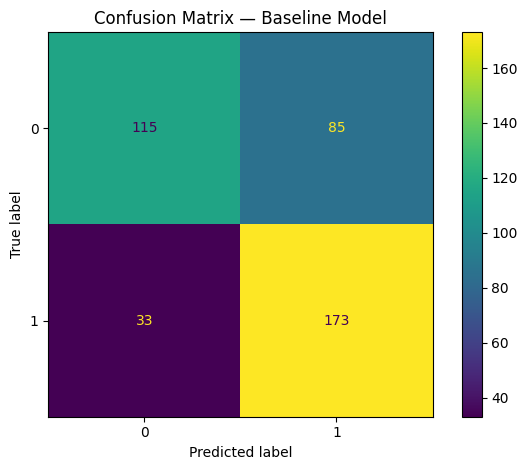

In [23]:
result = baseline_text_model(train_df)

In [24]:
print(f"Metrics: {result.get('metrics')}")

Metrics: {'accuracy': 0.7093596059113301, 'f1': 0.7456896551724138, 'roc_auc': 0.8322330097087379}


In [25]:
def random_forest_text_model(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
    max_features: int = 50000,
) -> Dict[str, Any]:
    """2nd Model: TF-IDF + RandomForest. Returns metrics and model artifacts."""

    X = df["body"].astype(str).values
    y = df["rule_violation"].astype(int).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=max_features, stop_words="english")
    Xtr = tfidf.fit_transform(X_train)
    Xte = tfidf.transform(X_test)

    clf = RandomForestClassifier(n_estimators=200)
    clf.fit(Xtr, y_train)

    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = float("nan")

    print("\2nd Model — TF-IDF + RandomForestClassifier")
    print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix — 2nd Model")
    plt.tight_layout()
    plt.show()

    return {
        "vectorizer": tfidf,
        "model": clf,
        "metrics": {"accuracy": acc, "f1": f1, "roc_auc": auc},
    }

nd Model — TF-IDF + RandomForestClassifier
Accuracy: 0.751 | F1: 0.749 | ROC-AUC: 0.829

Classification report:
               precision    recall  f1-score   support

           0      0.737     0.770     0.753       200
           1      0.766     0.733     0.749       206

    accuracy                          0.751       406
   macro avg      0.752     0.752     0.751       406
weighted avg      0.752     0.751     0.751       406



<Figure size 600x600 with 0 Axes>

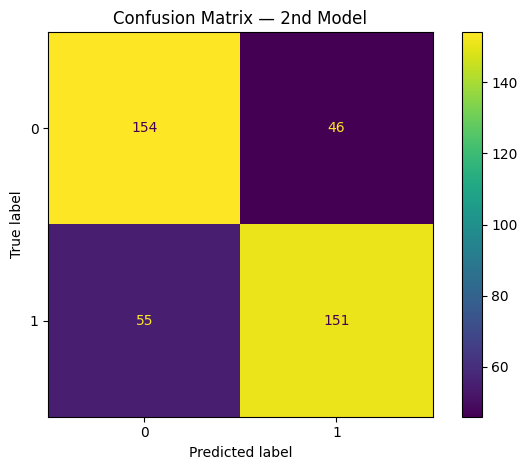

In [26]:
result = random_forest_text_model(train_df)

In [27]:
print(f"Metrics: {result.get('metrics')}")

Metrics: {'accuracy': 0.7512315270935961, 'f1': 0.7493796526054591, 'roc_auc': 0.8286529126213593}


<img src="https://images.unsplash.com/photo-1591040092219-081fb773589c" width=300></img>
